# California Housing Prices: Linear, Ridge, and Lasso Regression

**Problem statement:** Build a Linear Regression model to predict a continuous target variable, then apply Ridge and Lasso regularization. Compare coefficients, evaluate all three models using MAE, MSE, RMSE, and R², and conclude which model generalizes best.

**Dataset:** Kaggle California Housing Prices (`camnugent/california-housing-prices`)  
**Target:** `median_house_value`

## 1. Setup

This notebook keeps the workflow reproducible with a fixed random seed and a single train/test split for all models.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "median_house_value"

## 2. Load Data

The notebook first looks for the CSV in common local and Kaggle paths. If the file is not already present, it attempts to download the public Kaggle dataset with `kagglehub`.

In [2]:
candidate_paths = [
    Path("data/housing.csv"),
    Path("../data/housing.csv"),
    Path("/kaggle/input/california-housing-prices/housing.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    try:
        import kagglehub
        downloaded_dir = Path(kagglehub.dataset_download("camnugent/california-housing-prices"))
        data_path = next(downloaded_dir.rglob("housing.csv"))
    except Exception as exc:
        raise FileNotFoundError(
            "Could not find housing.csv locally or under /kaggle/input. "
            "Place the file at data/housing.csv or attach the Kaggle dataset."
        ) from exc

df = pd.read_csv(data_path)
print(f"Loaded data from: {data_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded data from: ../data/housing.csv
Shape: 20,640 rows x 10 columns


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Data Quality Checks

Before modeling, check missing values, duplicates, target range, and feature types.

In [3]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "duplicate_rows",
        "missing_cells",
        "columns_with_missing",
        "target_min",
        "target_median",
        "target_max",
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        int(df.duplicated().sum()),
        int(df.isna().sum().sum()),
        int((df.isna().sum() > 0).sum()),
        float(df[TARGET].min()),
        float(df[TARGET].median()),
        float(df[TARGET].max()),
    ],
})

display(quality_summary)
display(df.isna().sum().to_frame("missing_values").query("missing_values > 0"))
display(df.dtypes.to_frame("dtype"))

,metric,value
0,rows,20640.0
1,columns,10.0
2,duplicate_rows,0.0
3,missing_cells,207.0
4,columns_with_missing,1.0
5,target_min,14999.0
6,target_median,179700.0
7,target_max,500001.0


,missing_values
total_bedrooms,207


,dtype
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


## 4. Train/Test Split and Preprocessing

The same train/test split is used for all models. Numeric features are median-imputed and standardized; categorical features are imputed and one-hot encoded.

In [4]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Train rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Train rows: 16,512
Test rows: 4,128
Numeric features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


## 5. Fit Linear, Ridge, and Lasso Models

Ridge and Lasso use cross-validation on the training data to choose alpha from a log-spaced grid.

In [5]:
alpha_grid = np.logspace(-3, 3, 25)

model_specs = {
    "Linear Regression": LinearRegression(),
    "Ridge": RidgeCV(alphas=alpha_grid, cv=5),
    "Lasso": LassoCV(alphas=alpha_grid, cv=5, random_state=RANDOM_STATE, max_iter=100_000, n_jobs=-1),
}

fitted_models = {}
metric_rows = []

for model_name, estimator in model_specs.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    metric_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, predictions),
        "Selected Alpha": getattr(pipeline.named_steps["model"], "alpha_", np.nan),
    })
    fitted_models[model_name] = pipeline

metrics_df = pd.DataFrame(metric_rows).sort_values("RMSE").reset_index(drop=True)
metrics_display = metrics_df.copy()
for col in ["MAE", "MSE", "RMSE"]:
    metrics_display[col] = metrics_display[col].round(2)
metrics_display["R2"] = metrics_display["R2"].round(4)
metrics_display["Selected Alpha"] = metrics_display["Selected Alpha"].round(6)

display(metrics_display)

,Model,MAE,MSE,RMSE,R2,Selected Alpha
0,Linear Regression,50670.49,4.908291e+09,70059.19,0.6254,NaN
1,Lasso,50670.80,4.908330e+09,70059.48,0.6254,0.316228
2,Ridge,50674.50,4.908855e+09,70063.22,0.6254,0.562341


## 6. Compare Model Coefficients

Coefficients are shown on the preprocessed feature scale. Numeric variables are standardized, so their coefficients are comparable by magnitude. One-hot encoded category coefficients represent the model effect for each category indicator.

In [6]:
feature_names = fitted_models["Linear Regression"].named_steps["preprocess"].get_feature_names_out()
coef_df = pd.DataFrame({"Feature": feature_names})

for model_name, pipeline in fitted_models.items():
    coef_df[model_name] = pipeline.named_steps["model"].coef_.ravel()

coef_df["Max Abs Coef"] = coef_df[list(model_specs.keys())].abs().max(axis=1)
coef_comparison = coef_df.sort_values("Max Abs Coef", ascending=False).drop(columns="Max Abs Coef")

display(coef_comparison.round(2))

lasso_zero_count = int((coef_df["Lasso"].abs() < 1e-8).sum())
print(f"Lasso shrank {lasso_zero_count} of {len(coef_df)} coefficients to zero.")

,Feature,Linear Regression,Ridge,Lasso
10,ocean_proximity_ISLAND,117198.49,105347.09,134820.06
7,median_income,75167.77,75159.96,75166.03
9,ocean_proximity_INLAND,-58713.24,-55763.24,-39788.80
1,latitude,-54415.70,-54394.98,-54412.20
0,longitude,-53826.65,-53801.13,-53822.12
5,population,-43403.43,-43397.89,-43401.24
4,total_bedrooms,43068.18,43052.85,43064.54
11,ocean_proximity_NEAR BAY,-24063.23,-21087.53,-5131.03
8,ocean_proximity_<1H OCEAN,-18926.58,-15966.73,0.00
6,households,18382.20,18371.91,18377.35


Lasso shrank 1 of 13 coefficients to zero.


## 7. Visual Comparison

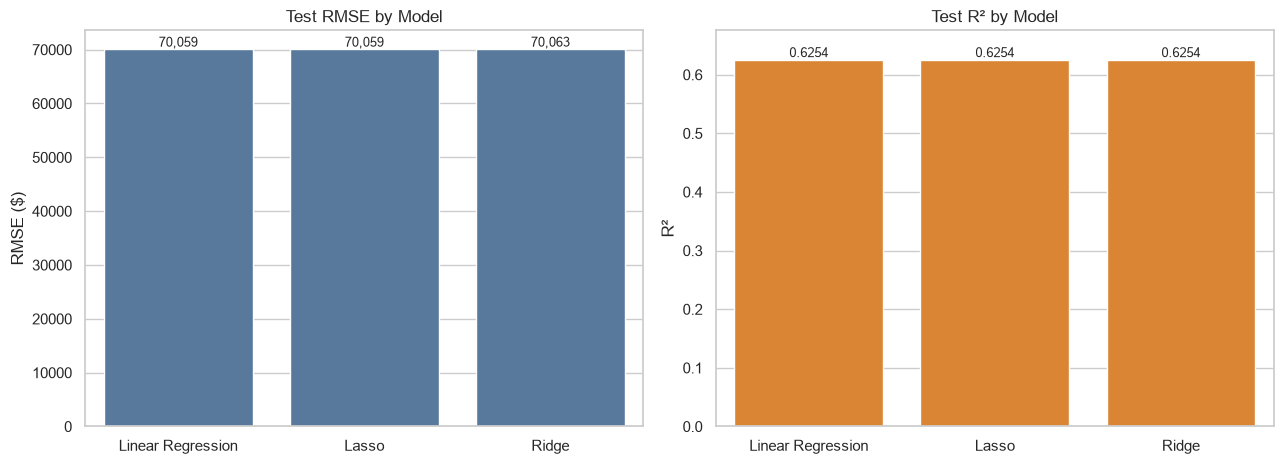

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=metrics_df, x="Model", y="RMSE", ax=axes[0], color="#4C78A8")
axes[0].set_title("Test RMSE by Model")
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE ($)")
for patch in axes[0].patches:
    axes[0].text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f"{patch.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

sns.barplot(data=metrics_df, x="Model", y="R2", ax=axes[1], color="#F58518")
axes[1].set_title("Test R² by Model")
axes[1].set_xlabel("")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, max(metrics_df["R2"]) + 0.05)
for patch in axes[1].patches:
    axes[1].text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height(),
        f"{patch.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

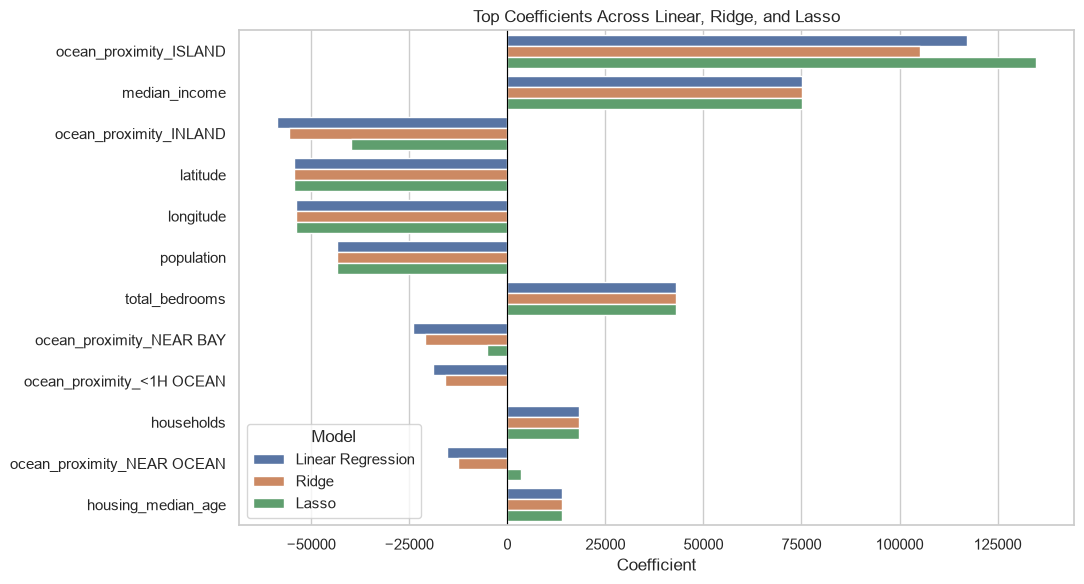

In [8]:
top_features = coef_df.sort_values("Max Abs Coef", ascending=False).head(12)
plot_df = top_features.melt(
    id_vars="Feature",
    value_vars=list(model_specs.keys()),
    var_name="Model",
    value_name="Coefficient",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, y="Feature", x="Coefficient", hue="Model")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top Coefficients Across Linear, Ridge, and Lasso")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 8. Conclusion

In [9]:
best_row = metrics_df.iloc[0]
linear_row = metrics_df.loc[metrics_df["Model"] == "Linear Regression"].iloc[0]
ridge_row = metrics_df.loc[metrics_df["Model"] == "Ridge"].iloc[0]
lasso_row = metrics_df.loc[metrics_df["Model"] == "Lasso"].iloc[0]

conclusion = f"""
**Best model:** {best_row['Model']} generalizes best on the held-out test set because it has the lowest RMSE (${best_row['RMSE']:,.0f}) and highest R² ({best_row['R2']:.4f}) among the three models. The differences are very small: Ridge and Lasso have nearly identical error to the plain Linear Regression model, so regularization did not materially improve predictive performance for this feature set. Ridge mainly shrank coefficients slightly, while Lasso added sparsity by reducing {lasso_zero_count} coefficient(s) to zero, showing regularization can simplify coefficients even when test accuracy stays almost unchanged.
"""

display(Markdown(conclusion))


**Best model:** Linear Regression generalizes best on the held-out test set because it has the lowest RMSE ($70,059) and highest R² (0.6254) among the three models. The differences are very small: Ridge and Lasso have nearly identical error to the plain Linear Regression model, so regularization did not materially improve predictive performance for this feature set. Ridge mainly shrank coefficients slightly, while Lasso added sparsity by reducing 1 coefficient(s) to zero, showing regularization can simplify coefficients even when test accuracy stays almost unchanged.


## 9. Submission Checklist

- Train/test split created with `random_state=42`
- Linear Regression, Ridge, and Lasso models trained on the same preprocessing pipeline
- MAE, MSE, RMSE, and R² comparison table included
- Coefficients compared across all three models
- 2–3 sentence conclusion included